# 2D Double Integrator (4D State): Robust CBF Comparison

State `(px, vx, py, vy)`, control `(ux, uy)`, walls `|px| ≤ 1`, `|py| ≤ 1`.
Same observation model as the 1D notebook (sigmoid position, linear velocity)
applied independently per axis.  Compares five policies:
CBF · R-CBF-QP · CBF+φ · G-CBF (NNV) · Duality CBF


In [12]:
import functools as ft
import itertools
import sys
sys.path.insert(0, '../../src')

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Rectangle
from matplotlib.collections import LineCollection
from typing import NamedTuple
import time

import jax_verify
from jax_verify.src import bound_propagation

from mrncbf.utils.jax_utils import jax_default_x32
from mrncbf.qp.min_norm_cbf import min_norm_cbf, gcbf_qp, rcbf_qp_linear, compute_rcbf_gammas

jax_default_x32()

# ── System parameters ────────────────────────────────────────────────────────
UMAX        = 1.0
PWALL       = 1.0
u_lb        = jnp.array([-UMAX, -UMAX])
u_ub        = jnp.array([ UMAX,  UMAX])
ALPHA_HOCBF = 5.0
ALPHA_QP    = 1.0
DT          = 0.05
T           = 300

# ── Reference schedule ────────────────────────────────────────────────────────
REF_INITIAL     = jnp.array([-0.7, -0.7])
REF_FINAL       = jnp.array([ 0.7,  0.7])
REF_SWITCH_STEP = 100

# ── Observation / estimator parameters ──────────────────────────────────────
OBS_A    = 4.0
OBS_B    = 4.0
OBS_BETA = 0.5
OBS_EPS  = jnp.array([0.1, 0.1, 0.1, 0.1])   # per-channel noise bound


## System dynamics and HOCBF

`f(x) = [vx, 0, vy, 0]ᵀ`,  `G(x) = [[0,0],[1,0],[0,0],[0,1]]`.
Four second-order wall constraints — one per face of the box.


In [13]:
def f(x):
    px, vx, py, vy = x
    return jnp.array([vx, 0.0, vy, 0.0])

def G(x):
    return jnp.array([[0., 0.],
                      [1., 0.],
                      [0., 0.],
                      [0., 1.]])

def h_raw(x):
    px, vx, py, vy = x
    return jnp.array([-(px + PWALL), px - PWALL,
                      -(py + PWALL), py - PWALL])

def B_hocbf(x, alpha=ALPHA_HOCBF):
    h = h_raw(x)
    px, vx, py, vy = x
    return jnp.array([
        -vx + alpha * h[0],   # left-x  wall  (px >= -1)
         vx + alpha * h[1],   # right-x wall  (px <=  1)
        -vy + alpha * h[2],   # left-y  wall  (py >= -1)
         vy + alpha * h[3],   # right-y wall  (py <=  1)
    ])

def nom_pol(x, ref):
    px, vx, py, vy = x
    ux = jnp.clip(-2.0*(px - ref[0]) - 1.5*vx, -UMAX, UMAX)
    uy = jnp.clip(-2.0*(py - ref[1]) - 1.5*vy, -UMAX, UMAX)
    return jnp.array([ux, uy])

def _gcbf_ingredients(x, alpha=ALPHA_HOCBF):
    hx_Vx  = jax.jacobian(ft.partial(B_hocbf, alpha=alpha))(x)
    h_V    = B_hocbf(x, alpha=alpha)
    h_Lf_V = hx_Vx @ f(x)
    h_LG_V = hx_Vx @ G(x)
    return h_V, h_Lf_V, h_LG_V

_NH = 4   # number of CBF constraints

def plot_xy(ax):
    """Draw wall box on an x-y axes."""
    rect = Rectangle((-PWALL, -PWALL), 2*PWALL, 2*PWALL,
                     fill=False, edgecolor='C3', lw=1.5, ls='--', zorder=4)
    ax.add_patch(rect)
    ax.set_xlim(-1.35, 1.35); ax.set_ylim(-1.35, 1.35)
    ax.set_aspect('equal'); ax.set_xlabel('px'); ax.set_ylabel('py')


## Observation model

Same per-axis sigmoid compression as the 1D notebook, ordered `(obs_px, obs_vx, obs_py, obs_vy)`.


In [14]:
def obs_fn(x):
    px, vx, py, vy = x
    obs_px = -1.0 / OBS_B * jnp.log(OBS_A / (px + OBS_A - 1.0) - 1.0)
    obs_py = -1.0 / OBS_B * jnp.log(OBS_A / (py + OBS_A - 1.0) - 1.0)
    obs_vx = vx / OBS_BETA
    obs_vy = vy / OBS_BETA
    return jnp.array([obs_px, obs_vx, obs_py, obs_vy])

def estimator_fn(obs):
    px_hat = OBS_A * jax.nn.sigmoid(OBS_B * obs[0]) - (OBS_A - 1.0)
    vx_hat = OBS_BETA * obs[1]
    py_hat = OBS_A * jax.nn.sigmoid(OBS_B * obs[2]) - (OBS_A - 1.0)
    vy_hat = OBS_BETA * obs[3]
    return jnp.array([px_hat, vx_hat, py_hat, vy_hat])

# Roundtrip sanity check
x_chk = jnp.array([0.3, -0.5, -0.6, 0.8])
err   = jnp.max(jnp.abs(estimator_fn(obs_fn(x_chk)) - x_chk))
print(f"Roundtrip max error: {float(err):.2e}  (should be ~0)")


Roundtrip max error: 1.79e-07  (should be ~0)


In [15]:
class StateBounds(NamedTuple):
    lo: jnp.ndarray
    hi: jnp.ndarray

@jax.jit
def nnv_state_bounds(obs, obs_eps):
    interval_bounds = jax_verify.IntervalBound(obs - obs_eps, obs + obs_eps)
    jittable_bounds = interval_bounds.to_jittable()
    def propagate(inp_bound):
        (inp_bound,) = bound_propagation.unjit_inputs(inp_bound)
        bounds = jax_verify.backward_crown_bound_propagation(estimator_fn, inp_bound)
        return jnp.array(bounds.lower), jnp.array(bounds.upper)
    lo, hi = propagate(jittable_bounds)
    return StateBounds(lo=lo.flatten(), hi=hi.flatten())

# Sanity check
x_t = jnp.array([0.5, 0.3, -0.4, -0.2])
sb  = nnv_state_bounds(obs_fn(x_t), OBS_EPS)
print(f"NNV bounds at x={np.array(x_t)}:")
print(f"  lo = {np.array(sb.lo).round(4)}")
print(f"  hi = {np.array(sb.hi).round(4)}")
print(f"  widths = {np.array(sb.hi - sb.lo).round(4)}")


NNV bounds at x=[ 0.5  0.3 -0.4 -0.2]:
  lo = [ 0.2973  0.25   -0.7818 -0.25  ]
  hi = [ 0.675  0.35  -0.036 -0.15 ]
  widths = [0.3777 0.1    0.7458 0.1   ]


## Rollout infrastructure

`proj_grad_max_box` + G-CBF + step functions for all five policies.
Reference schedule: shape `(T, 2)` scanned alongside step indices.


In [34]:
BASE_KEY = jax.random.PRNGKey(0)
OBS_PTB  = OBS_EPS * jnp.array([1.0, 0.0, 1.0, 0.0])   # bias position channels only

refs = jnp.stack([
    jnp.where(jnp.arange(T) >= REF_SWITCH_STEP, REF_FINAL[0], REF_INITIAL[0]),
    jnp.where(jnp.arange(T) >= REF_SWITCH_STEP, REF_FINAL[1], REF_INITIAL[1]),
], axis=1)   # (T, 2)

ts      = np.arange(T + 1) * DT
ts_ctrl = np.arange(T) * DT

def _make_rollout_aux(step_fn):
    @jax.jit
    def rollout(x0):
        _, (xs, xhats, los, his) = jax.lax.scan(
            step_fn, x0, (jnp.arange(T), refs))
        return jnp.concatenate([x0[None], xs], axis=0), xhats, los, his
    return rollout

def _perturb_obs(x, key):
    obs = obs_fn(x) + jax.random.uniform(key, OBS_PTB.shape,
                                          minval=OBS_PTB - 1e-4, maxval=OBS_PTB)
    return obs, estimator_fn(obs)

# ── proj-grad and G-CBF ───────────────────────────────────────────────────────
def proj_grad_max_box(scalar_fn, lo, hi, n_restarts, n_steps, lr, key):
    x0s = lo[None] + jax.random.uniform(key, (n_restarts, lo.shape[0])) * (hi - lo)
    def run_one(x0):
        def step(x, _):
            g = jax.grad(scalar_fn)(x)
            return jnp.clip(x + lr * g, lo, hi), None
        x_star, _ = jax.lax.scan(step, x0, None, length=n_steps)
        return scalar_fn(x_star), x_star
    vals, xs = jax.vmap(run_one)(x0s)
    best = jnp.argmax(vals)
    return vals[best], xs[best]

@ft.partial(jax.jit, static_argnames=("n_restarts", "n_steps"))
def gcbf_pol_gradopt_box(xhat, lo, hi, rng_key, ref,
                          alpha_qp=ALPHA_QP, n_restarts=1, n_steps=10, lr=0.05):
    keys = jax.random.split(rng_key, 3 * _NH)
    def worst_h_V_i(i, key):
        _, x = proj_grad_max_box(lambda x: B_hocbf(x)[i], lo, hi, n_restarts, n_steps, lr, key)
        return _gcbf_ingredients(x)[0][i]
    def worst_Lf_V_i(i, key):
        _, x = proj_grad_max_box(lambda x: _gcbf_ingredients(x)[1][i], lo, hi, n_restarts, n_steps, lr, key)
        return _gcbf_ingredients(x)[1][i]
    def worst_LG_V_i(i, key):
        _, x = proj_grad_max_box(lambda x: -jnp.linalg.norm(_gcbf_ingredients(x)[2][i]),
                                  lo, hi, n_restarts, n_steps, lr, key)
        return _gcbf_ingredients(x)[2][i]
    ci = jnp.arange(_NH)
    h_V_wc  = jax.vmap(worst_h_V_i )(ci, keys[       : _NH  ])
    h_Lf_wc = jax.vmap(worst_Lf_V_i)(ci, keys[  _NH  : 2*_NH])
    h_LG_wc = jax.vmap(worst_LG_V_i)(ci, keys[2*_NH  :      ])
    u_opt, r, _ = gcbf_qp(alpha_qp, u_lb, u_ub, h_V_wc, h_Lf_wc, h_LG_wc,
                           nom_pol(xhat, ref), relax_eps2=0.1)
    return u_opt, r, h_V_wc, h_Lf_wc, h_LG_wc

# ── CBF (vanilla) ─────────────────────────────────────────────────────────────
def _cbf_step_aux(x, step_ref):
    step_idx, ref = step_ref
    key = jax.random.fold_in(BASE_KEY, step_idx)
    obs, xhat = _perturb_obs(x, key)
    h_V   = B_hocbf(xhat)
    hx_Vx = jax.jacobian(B_hocbf)(xhat)
    u, _, _ = min_norm_cbf(ALPHA_QP, u_lb, u_ub, h_V, hx_Vx,
                           f(xhat), G(xhat), nom_pol(xhat, ref), relax_eps2=0.1)
    return x + DT*(f(x) + G(x) @ u), (x, xhat, xhat, xhat)

rollout_cbf_aux = _make_rollout_aux(_cbf_step_aux)

# ── G-CBF (NNV) ───────────────────────────────────────────────────────────────
def _gcbf_nnv_step_aux(x, step_ref):
    step_idx, ref = step_ref
    key = jax.random.fold_in(BASE_KEY, step_idx)
    obs_key, qp_key = jax.random.split(key)
    obs, xhat = _perturb_obs(x, obs_key)
    sb = nnv_state_bounds(obs, OBS_EPS)
    u, _, _, _, _ = gcbf_pol_gradopt_box(xhat, sb.lo, sb.hi, qp_key, ref)
    return x + DT*(f(x) + G(x) @ u), (x, xhat, sb.lo, sb.hi)

rollout_gcbf_nnv_aux = _make_rollout_aux(_gcbf_nnv_step_aux)

print("Defined step functions.")


Defined step functions.


In [35]:
x0s = jnp.array([
    [ 0.7,  0.5,  0.7,  0.5],
    [-0.7, -0.5, -0.7, -0.5],
    [ 0.7, -0.5, -0.7,  0.5],
    [-0.7,  0.5,  0.7, -0.5],
])
X0_IDX  = 0
x0_demo = x0s[X0_IDX]

ref_sched = np.where((np.arange(T) >= REF_SWITCH_STEP)[:, None],
                     np.array(REF_FINAL)[None, :],
                     np.array(REF_INITIAL)[None, :])   # (T, 2)

print("Compiling CBF and G-CBF rollouts...")
x_dummy = jnp.zeros(4)
rollout_cbf_aux(x_dummy)
rollout_gcbf_nnv_aux(x_dummy)
print("Done.")

results_aux = {}
for name, fn in [("CBF", rollout_cbf_aux), ("G-CBF (NNV)", rollout_gcbf_nnv_aux)]:
    xs, xhats, los, his = jax.device_get(fn(x0_demo))
    results_aux[name] = dict(xs=xs, xhats=xhats, los=los, his=his)
    viol_x = bool(np.any(np.abs(xs[:, 0]) > PWALL + 1e-3))
    viol_y = bool(np.any(np.abs(xs[:, 2]) > PWALL + 1e-3))
    print(f"  {name:<16}  violated x: {viol_x}  violated y: {viol_y}")


Compiling CBF and G-CBF rollouts...
Done.
  CBF               violated x: True  violated y: True
  G-CBF (NNV)       violated x: False  violated y: False


## Learning φ: worst-case CBF drift correction

Same as in the 1D notebook but operating on the 4D state.
φ[i] ≥ 0 bounds the worst-case excess of `Lf_B[i] + α·B[i]` over its nominal value.


In [36]:
import flax.linen as nn
import optax

@ft.partial(jax.jit, static_argnames=("n_restarts", "n_steps"))
def phi_true_fn(xhat, lo, hi, rng_key, alpha=ALPHA_QP,
                n_restarts=8, n_steps=60, lr=0.05):
    h_nom  = B_hocbf(xhat)
    Lf_nom = jax.jacobian(B_hocbf)(xhat) @ f(xhat)
    def worst_i(i, key):
        _, x_wc = proj_grad_max_box(
            lambda x: (jax.jacobian(B_hocbf)(x) @ f(x))[i] + alpha * B_hocbf(x)[i],
            lo, hi, n_restarts, n_steps, lr, key)
        h_wc_i  = B_hocbf(x_wc)[i]
        Lf_wc_i = (jax.jacobian(B_hocbf)(x_wc) @ f(x_wc))[i]
        return (Lf_wc_i + alpha*h_wc_i) - (Lf_nom[i] + alpha*h_nom[i])
    keys = jax.random.split(rng_key, _NH)
    return jax.vmap(worst_i)(jnp.arange(_NH), keys)

# Quick sanity check
x_chk = jnp.array([0.3, -0.5, -0.4, 0.6])
obs_chk = obs_fn(x_chk)
sb_chk  = nnv_state_bounds(obs_chk, OBS_EPS)
phi_got = phi_true_fn(x_chk, sb_chk.lo, sb_chk.hi, jax.random.PRNGKey(0))
print(f"phi_true at x_chk: {np.array(phi_got).round(4)}  (all should be >= 0)")


phi_true at x_chk: [1.6076 1.455  2.2092 2.12  ]  (all should be >= 0)


In [37]:
N_TRAIN, N_TEST = 12000, 4000
x_lo_phi = jnp.array([-0.95, -2.5, -0.95, -2.5])
x_hi_phi = jnp.array([ 0.95,  2.5,  0.95,  2.5])

rng_phi = jax.random.PRNGKey(7)
rng_phi, rng_tr, rng_te = jax.random.split(rng_phi, 3)

xhat_train = x_lo_phi + jax.random.uniform(rng_tr, (N_TRAIN, 4)) * (x_hi_phi - x_lo_phi)
xhat_test  = x_lo_phi + jax.random.uniform(rng_te, (N_TEST,  4)) * (x_hi_phi - x_lo_phi)

def _get_bounds(xhat_arr):
    los, his = [], []
    for xhat in np.array(xhat_arr):
        obs = obs_fn(jnp.array(xhat))
        sb  = nnv_state_bounds(obs, OBS_EPS)
        los.append(sb.lo); his.append(sb.hi)
    return jnp.array(los), jnp.array(his)

print("Computing NNV bounds for training set...")
los_train, his_train = _get_bounds(xhat_train)
los_test,  his_test  = _get_bounds(xhat_test)

keys_tr = jax.random.split(rng_phi, N_TRAIN)
keys_te = jax.random.split(jax.random.PRNGKey(99), N_TEST)

print("Computing phi_true for training set (vmapped gradient ascent)...")
phi_train = jax.vmap(phi_true_fn)(xhat_train, los_train, his_train, keys_tr)
print("Computing phi_true for test set...")
phi_test  = jax.vmap(phi_true_fn)(xhat_test,  los_test,  his_test,  keys_te)

print(f"phi stats — mean: {float(jnp.mean(phi_train)):.4f}  "
      f"max: {float(jnp.max(phi_train)):.4f}  "
      f"min: {float(jnp.min(phi_train)):.4f}")


Computing NNV bounds for training set...
Computing phi_true for training set (vmapped gradient ascent)...
Computing phi_true for test set...
phi stats — mean: 1.6946  max: 2.2973  min: 0.3978


PhiNet params: 4740
Epoch 100  train_loss=8.27e-05  val_mse=1.06e-04
Epoch 200  train_loss=3.04e-05  val_mse=2.43e-05
Epoch 300  train_loss=2.36e-05  val_mse=2.22e-05
Epoch 400  train_loss=3.07e-05  val_mse=3.73e-05


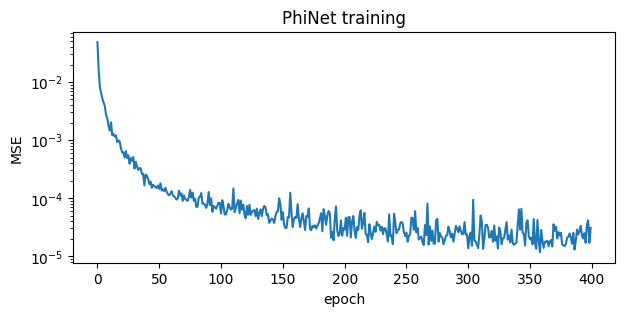

In [38]:
class PhiNet(nn.Module):
    hidden_dims: tuple = (64, 64)
    n_constraints: int = _NH

    @nn.compact
    def __call__(self, xhat):
        x = xhat
        for h in self.hidden_dims:
            x = nn.Dense(h)(x)
            x = nn.tanh(x)
        return nn.softplus(nn.Dense(self.n_constraints)(x))

phi_net    = PhiNet()
phi_key    = jax.random.PRNGKey(0)
phi_params = phi_net.init(phi_key, jnp.zeros(4))['params']
optimizer  = optax.adam(3e-3)
opt_state  = optimizer.init(phi_params)
print(f"PhiNet params: {sum(p.size for p in jax.tree_util.tree_leaves(phi_params))}")

BATCH_SIZE = 256
N_EPOCHS   = 400

@jax.jit
def train_step(params, opt_state, xhat_b, phi_b):
    def loss_fn(p):
        pred = jax.vmap(lambda x: phi_net.apply({'params': p}, x))(xhat_b)
        return jnp.mean((pred - phi_b)**2)
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, new_opt = optimizer.update(grads, opt_state, params)
    return optax.apply_updates(params, updates), new_opt, loss

rng_ep = jax.random.PRNGKey(42)
train_losses = []
for epoch in range(N_EPOCHS):
    rng_ep, rng_shuf = jax.random.split(rng_ep)
    perm = jax.random.permutation(rng_shuf, N_TRAIN)
    ep_loss = 0.0
    for b in range(0, N_TRAIN, BATCH_SIZE):
        idx = perm[b : b + BATCH_SIZE]
        phi_params, opt_state, ep_loss = train_step(
            phi_params, opt_state, xhat_train[idx], phi_train[idx])
    train_losses.append(float(ep_loss))
    if (epoch + 1) % 100 == 0:
        pred_val = jax.vmap(lambda x: phi_net.apply({'params': phi_params}, x))(xhat_test)
        val_mse  = float(jnp.mean((pred_val - phi_test)**2))
        print(f"Epoch {epoch+1:3d}  train_loss={ep_loss:.2e}  val_mse={val_mse:.2e}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.semilogy(train_losses)
ax.set_xlabel("epoch"); ax.set_ylabel("MSE"); ax.set_title("PhiNet training")
plt.show()


## Policy comparison: all five filters

R-CBF-QP, CBF+φ, and Duality CBF step functions are defined here.
Duality CBF uses 16 Fibonacci-sphere directions per constraint to build a
polytopic over-approximation of the 3D uncertainty image `(LG_h_i ∈ ℝ², Lf_h_i + αh_i ∈ ℝ)`.


Running R-CBF-QP, CBF+phi, Duality CBF rollouts (includes JIT compile)...
  R-CBF-QP          violated x: True  y: True
  CBF + phi         violated x: False  y: False
  Duality CBF       violated x: False  y: False


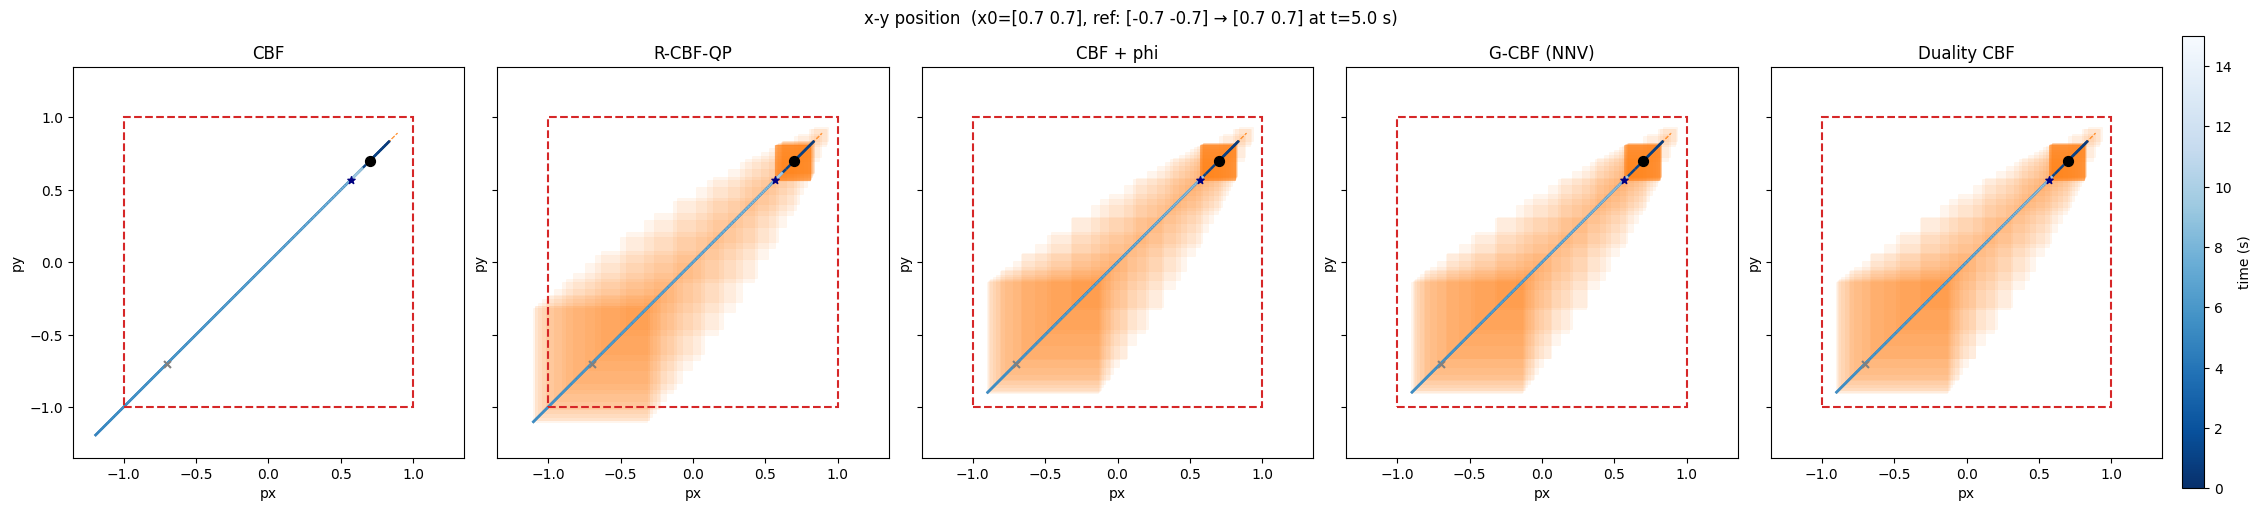

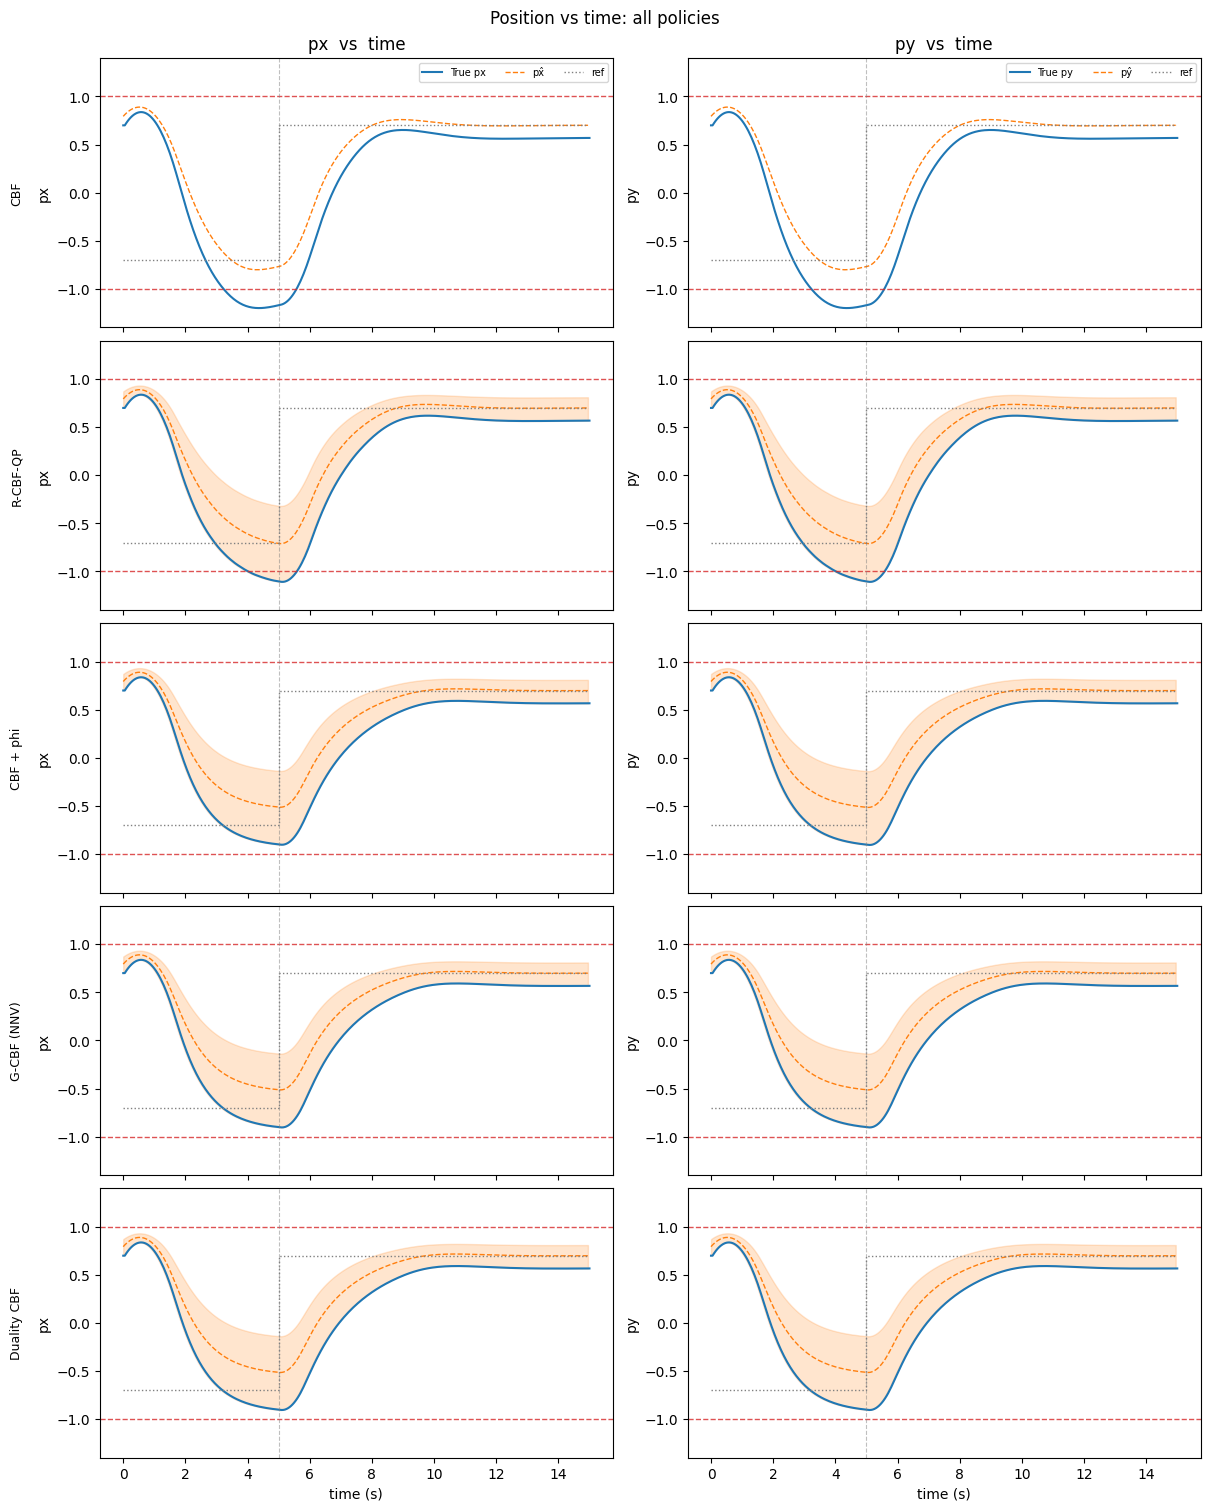

In [39]:
N_RCBF_SAMPLES = 20
N_PLANES_DUAL  = 2  # directions on S² for 3D image (nu+1 = 3)

# Fibonacci sphere directions — computed once as concrete numpy arrays
_golden    = (1 + np.sqrt(5)) / 2
_ks        = np.arange(N_PLANES_DUAL)
_theta_fib = np.arccos(1 - 2*(_ks + 0.5) / N_PLANES_DUAL)
_phi_fib   = 2*np.pi*_ks / _golden
_DUAL_DIRS = np.stack([
    np.sin(_theta_fib)*np.cos(_phi_fib),   # d_ux  (LG direction for u_x)
    np.sin(_theta_fib)*np.sin(_phi_fib),   # d_uy  (LG direction for u_y)
    np.cos(_theta_fib),                    # d_lf  (Lf+αh direction)
], axis=1)   # (N_PLANES_DUAL, 3)

# ── R-CBF-QP ─────────────────────────────────────────────────────────────────
def _rcbf_step_aux(x, step_ref):
    step_idx, ref = step_ref
    key = jax.random.fold_in(BASE_KEY, step_idx)
    obs_key, samp_key = jax.random.split(key)
    obs, xhat = _perturb_obs(x, obs_key)
    sb = nnv_state_bounds(obs, OBS_EPS)
    lo, hi = sb.lo, sb.hi
    x_pert = lo[None] + jax.random.uniform(samp_key, (N_RCBF_SAMPLES, 4)) * (hi - lo)
    h_V_nom   = B_hocbf(xhat)
    hx_Vx_nom = jax.jacobian(B_hocbf)(xhat)
    u_nom     = nom_pol(xhat, ref)
    h_V_pert   = jax.vmap(B_hocbf)(x_pert)
    hx_Vx_pert = jax.vmap(jax.jacobian(B_hocbf))(x_pert)
    f_pert     = jax.vmap(f)(x_pert)
    G_pert     = jax.vmap(G)(x_pert)
    u_nom_pert = jax.vmap(lambda xp: nom_pol(xp, ref))(x_pert)
    gamma1, gamma2 = compute_rcbf_gammas(
        alpha=ALPHA_QP, u_lb=u_lb, u_ub=u_ub,
        h_V_nom=h_V_nom, hx_Vx_nom=hx_Vx_nom,
        f_nom=f(xhat), G_nom=G(xhat), u_nom_base=u_nom,
        h_V_pert=h_V_pert, hx_Vx_pert=hx_Vx_pert,
        f_pert=f_pert, G_pert=G_pert, u_nom_pert=u_nom_pert, n_grid=50)
    u, _, _ = rcbf_qp_linear(ALPHA_QP, u_lb, u_ub,
                              h_V_nom, hx_Vx_nom, f(xhat), G(xhat), u_nom,
                              gamma1=gamma1, gamma2=gamma2, relax_eps2=0.1)
    return x + DT*(f(x) + G(x) @ u), (x, xhat, lo, hi)

rollout_rcbf_aux = _make_rollout_aux(_rcbf_step_aux)

# ── CBF + phi ─────────────────────────────────────────────────────────────────
_phi_params_frozen = phi_params

def _cbf_phi_step_aux(x, step_ref):
    step_idx, ref = step_ref
    key = jax.random.fold_in(BASE_KEY, step_idx)
    obs_key, _ = jax.random.split(key)
    obs, xhat = _perturb_obs(x, obs_key)
    sb    = nnv_state_bounds(obs, OBS_EPS)
    phi   = phi_net.apply({'params': _phi_params_frozen}, xhat)
    h_V   = B_hocbf(xhat)
    hx_Vx = jax.jacobian(B_hocbf)(xhat)
    h_tight = h_V + phi / ALPHA_QP
    u, _, _ = min_norm_cbf(ALPHA_QP, u_lb, u_ub, h_tight, hx_Vx,
                           f(xhat), G(xhat), nom_pol(xhat, ref), relax_eps2=0.1)
    return x + DT*(f(x) + G(x) @ u), (x, xhat, sb.lo, sb.hi)

rollout_cbf_phi_aux = _make_rollout_aux(_cbf_phi_step_aux)

# ── Duality CBF (Nanayakkara et al. 2024) ────────────────────────────────────
# For each of _NH constraints and N_PLANES_DUAL sphere directions, find the
# extreme point of the 3D image {(LG_h_i, Lf_h_i+alpha*h_i)} over the NNV box.
def _duality_step_aux(x, step_ref):
    step_idx, ref    = step_ref
    key              = jax.random.fold_in(BASE_KEY, step_idx)
    obs_key, opt_key = jax.random.split(key)
    obs, xhat = _perturb_obs(x, obs_key)
    sb = nnv_state_bounds(obs, OBS_EPS)
    lo, hi = sb.lo, sb.hi
    u_nom_val = nom_pol(xhat, ref)

    def _ingr(xi):
        h  = B_hocbf(xi)
        Jh = jax.jacobian(B_hocbf)(xi)
        return h, Jh @ f(xi), Jh @ G(xi)   # (nh,), (nh,), (nh, nu)

    h_pts, Lf_pts, LG_pts = [], [], []
    for i in range(_NH):
        for j in range(N_PLANES_DUAL):
            d   = _DUAL_DIRS[j]   # concrete numpy (3,)
            k_ij = jax.random.fold_in(opt_key, i * N_PLANES_DUAL + j)

            def _dir_obj(xi, _d=d, _i=i):
                h, Lf_h, LG_h = _ingr(xi)
                return (_d[0]*LG_h[_i, 0] + _d[1]*LG_h[_i, 1]
                        + _d[2]*(Lf_h[_i] + ALPHA_QP*h[_i]))

            _, x_star = proj_grad_max_box(_dir_obj, lo, hi,
                                           n_restarts=4, n_steps=30, lr=0.05, key=k_ij)
            h_s, Lf_s, LG_s = _ingr(x_star)
            h_pts.append(h_s[i])
            Lf_pts.append(Lf_s[i])
            LG_pts.append(LG_s[i])   # (nu,)

    h_V_all  = jnp.stack(h_pts)    # (nh * N_PLANES_DUAL,)
    h_Lf_all = jnp.stack(Lf_pts)
    h_LG_all = jnp.stack(LG_pts)   # (nh * N_PLANES_DUAL, nu)

    u, _, _ = gcbf_qp(ALPHA_QP, u_lb, u_ub,
                       h_V_all, h_Lf_all, h_LG_all, u_nom_val, relax_eps2=0.1)
    return x + DT*(f(x) + G(x) @ u), (x, xhat, lo, hi)

rollout_duality_aux = _make_rollout_aux(_duality_step_aux)

# ── Run all demo rollouts ─────────────────────────────────────────────────────
print("Running R-CBF-QP, CBF+phi, Duality CBF rollouts (includes JIT compile)...")
for label, fn in [("R-CBF-QP",    rollout_rcbf_aux),
                  ("CBF + phi",   rollout_cbf_phi_aux),
                  ("Duality CBF", rollout_duality_aux)]:
    xs, xhats, los, his = jax.device_get(fn(x0_demo))
    results_aux[label] = dict(xs=xs, xhats=xhats, los=los, his=his)
    viol_x = bool(np.any(np.abs(xs[:, 0]) > PWALL + 1e-3))
    viol_y = bool(np.any(np.abs(xs[:, 2]) > PWALL + 1e-3))
    print(f"  {label:<16}  violated x: {viol_x}  y: {viol_y}")

ALL_ROLLOUTS = [
    ("CBF",          results_aux["CBF"]),
    ("R-CBF-QP",     results_aux["R-CBF-QP"]),
    ("CBF + phi",    results_aux["CBF + phi"]),
    ("G-CBF (NNV)",  results_aux["G-CBF (NNV)"]),
    ("Duality CBF",  results_aux["Duality CBF"]),
]

# ── x-y position trajectories ────────────────────────────────────────────────
BOX_STRIDE = 5
n_pol = len(ALL_ROLLOUTS)
fig, axes = plt.subplots(1, n_pol, figsize=(4.5*n_pol, 5),
                         layout="constrained", sharex=True, sharey=True)
for ax, (name, d) in zip(axes, ALL_ROLLOUTS):
    xs, xhats, los, his = d['xs'], d['xhats'], d['los'], d['his']
    # True trajectory coloured by time
    pts  = np.stack([xs[:, 0], xs[:, 2]], axis=1).reshape(-1, 1, 2)
    segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
    lc   = LineCollection(segs, cmap='Blues_r',
                          norm=plt.Normalize(0, T*DT), lw=1.8, zorder=3)
    lc.set_array(np.arange(T+1)*DT)
    ax.add_collection(lc)
    # Estimated position
    ax.plot(xhats[:, 0], xhats[:, 2], color='C1', lw=0.8, ls='--', alpha=0.7, label='x̂')
    # Uncertainty boxes at every BOX_STRIDE steps
    if name != 'CBF':
        for i in range(0, T, BOX_STRIDE):
            w = float(his[i, 0] - los[i, 0])
            h = float(his[i, 2] - los[i, 2])
            rect = Rectangle((float(los[i, 0]), float(los[i, 2])), w, h,
                              lw=0.4, edgecolor='C1', facecolor='C1', alpha=0.07, zorder=1)
            ax.add_patch(rect)
    # Start / end markers
    ax.scatter(xs[0, 0],  xs[0, 2],  s=50, color='k',    zorder=7)
    ax.scatter(xs[-1, 0], xs[-1, 2], s=30, color='navy', marker='*', zorder=7)
    # Reference points
    ax.scatter(*REF_INITIAL, s=25, color='gray', marker='x', zorder=6)
    ax.scatter(*REF_FINAL,   s=25, color='gray', marker='+', zorder=6)
    plot_xy(ax)
    ax.set_title(name)

fig.colorbar(lc, ax=axes[-1], label='time (s)')
fig.suptitle(
    f'x-y position  (x0={np.array(x0_demo)[[0,2]].round(2)}, '
    f'ref: {np.array(REF_INITIAL)} → {np.array(REF_FINAL)} at t={REF_SWITCH_STEP*DT:.1f} s)'
)
plt.show()

# ── x and y position vs time ─────────────────────────────────────────────────
fig2, axes2 = plt.subplots(n_pol, 2, figsize=(12, 3*n_pol),
                            sharex=True, sharey='col', layout="constrained")
for row, (name, d) in enumerate(ALL_ROLLOUTS):
    xs, xhats, los, his = d['xs'], d['xhats'], d['los'], d['his']
    for col, (xi, vi, label_pos) in enumerate([(0, 1, 'px'), (2, 3, 'py')]):
        ax = axes2[row, col]
        if name != 'CBF':
            ax.fill_between(ts_ctrl, los[:, xi], his[:, xi],
                            color='C1', alpha=0.2, label='NNV bounds')
        ax.plot(ts,      xs[:, xi],    color='C0', lw=1.5, label=f'True {label_pos}')
        ax.plot(ts_ctrl, xhats[:, xi], color='C1', lw=1.0, ls='--', label=f'{label_pos}̂')
        ax.step(ts_ctrl, ref_sched[:, col], color='gray', lw=1.0, ls=':', where='post', label='ref')
        ax.axhline( PWALL, color='C3', lw=1.0, ls='--', alpha=0.8)
        ax.axhline(-PWALL, color='C3', lw=1.0, ls='--', alpha=0.8)
        ax.axvline(REF_SWITCH_STEP*DT, color='gray', lw=0.8, ls='--', alpha=0.5)
        ax.set_ylim(-1.4, 1.4)
        ax.set_ylabel(label_pos)
        if row == 0:
            ax.set_title(f'{label_pos}  vs  time')
            ax.legend(fontsize=7, ncol=4)
    axes2[row, 0].text(-0.15, 0.5, name, transform=axes2[row, 0].transAxes,
                       va='center', ha='right', fontsize=9, rotation=90)
axes2[-1, 0].set_xlabel('time (s)')
axes2[-1, 1].set_xlabel('time (s)')
fig2.suptitle('Position vs time: all policies')
plt.show()


Timing 5 rollouts each  (T=300 steps)

  Policy              Mean (s)     Std (s)   Per-step (ms)
  --------------------------------------------------------
  CBF                   0.1018      0.0058           0.339
  R-CBF-QP              0.1284      0.0004           0.428
  CBF + phi             0.1342      0.0002           0.447
  G-CBF (NNV)           0.1724      0.0003           0.575
  Duality CBF           0.6280      0.0008           2.093


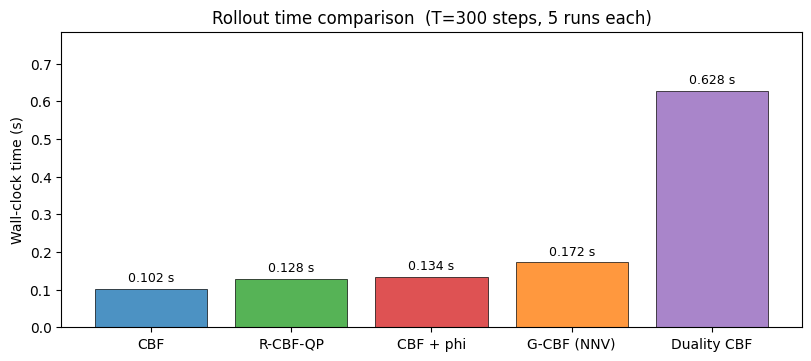

: 

In [ ]:
ROLLOUT_FNS = [
    ("CBF",          rollout_cbf_aux),
    ("R-CBF-QP",     rollout_rcbf_aux),
    ("CBF + phi",    rollout_cbf_phi_aux),
    ("G-CBF (NNV)",  rollout_gcbf_nnv_aux),
    ("Duality CBF",  rollout_duality_aux),
]
N_REPEATS = 5

print(f"Timing {N_REPEATS} rollouts each  (T={T} steps)\n")
print(f"  {'Policy':<16}  {'Mean (s)':>10}  {'Std (s)':>10}  {'Per-step (ms)':>14}")
print("  " + "-" * 56)

timing_results = {}
for name, fn in ROLLOUT_FNS:
    times = []
    for _ in range(N_REPEATS):
        t0 = time.perf_counter()
        jax.block_until_ready(fn(x0_demo))
        times.append(time.perf_counter() - t0)
    mean_t = float(np.mean(times))
    std_t  = float(np.std(times))
    timing_results[name] = mean_t
    print(f"  {name:<16}  {mean_t:>10.4f}  {std_t:>10.4f}  {mean_t/T*1000:>14.3f}")

fig, ax = plt.subplots(figsize=(8, 3.5), layout="constrained")
names  = [n for n, _ in ROLLOUT_FNS]
values = [timing_results[n] for n in names]
colors = ["C0", "C2", "C3", "C1", "C4"]
bars = ax.bar(names, values, color=colors, alpha=0.8, edgecolor="k", linewidth=0.6)
ax.bar_label(bars, fmt="{:.3f} s", padding=3, fontsize=9)
ax.set_ylabel("Wall-clock time (s)")
ax.set_title(f"Rollout time comparison  (T={T} steps, {N_REPEATS} runs each)")
ax.set_ylim(0, max(values)*1.25)
plt.show()
